Objetivo:
Analizar la relación entre el precio del petróleo y las principales compañías energéticas.

Pregunta:
¿El petróleo mueve a las petroleras o las petroleras anticipan el petróleo?

Hipótesis:
- Relación contemporánea fuerte
- Relación predictiva débil
- Posible dependencia condicional en eventos extremos


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from data_utils import load_data

In [2]:
df, returns = load_data()

print(df.tail())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  oil        rep         bp      shell       exxon     chevron
Date                                                                          
2025-12-23  62.380001  15.301819  34.137669  72.393661  118.629288  149.051910
2025-12-24  62.240002  15.316364  33.871124  72.165787  118.430618  149.042023
2025-12-29  61.939999  15.413334  34.009331  72.443207  119.731941  149.527267
2025-12-30  61.919998  15.500607  34.305492  73.146629  120.188896  150.834473
2025-12-31  60.849998  15.442425  34.285748  72.799873  119.543198  150.933517


In [3]:
returns = df.pct_change().dropna()

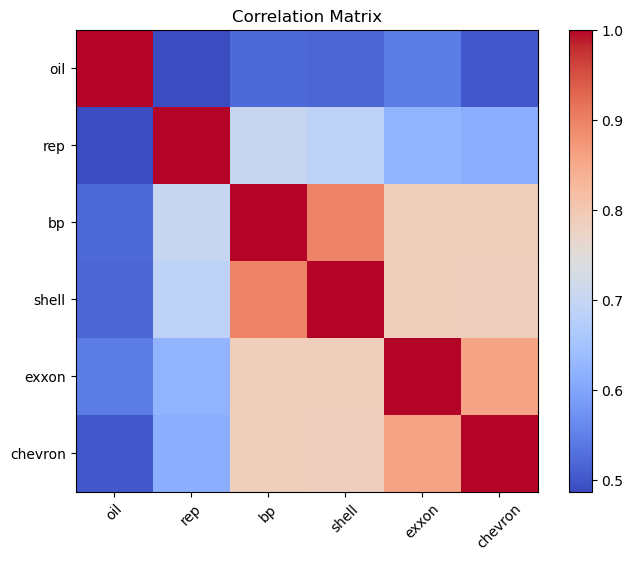

In [4]:
corr = returns.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

Damos la correlación con desfase es decir si el valor del petróleo predice el valor de las pretroleras:

In [5]:
for col in ["rep", "bp", "shell", "exxon", "chevron"]:
    
    corr = returns["oil"].shift(1).corr(returns[col])
    
    print(f"Oil → {col}: {corr:.4f}")

Oil → rep: 0.0615
Oil → bp: -0.0229
Oil → shell: -0.0509
Oil → exxon: -0.0182
Oil → chevron: 0.0250


Ahora damos el inverso:

In [6]:
for col in ["rep", "bp", "shell", "exxon", "chevron"]:
    
    corr = returns[col].shift(1).corr(returns["oil"])
    
    print(f"{col} → Oil: {corr:.4f}")

rep → Oil: 0.0467
bp → Oil: 0.0562
shell → Oil: 0.0475
exxon → Oil: 0.0764
chevron → Oil: 0.0235


In [7]:
cond = returns["shell"] > 0.01

print("Media petróleo general:", returns["oil"].mean())
print("Media petróleo cuando Shell sube:", returns["oil"][cond].mean())

Media petróleo general: 0.00030017786999678793
Media petróleo cuando Shell sube: 0.016039563600971207


Vemos como claramente cambia en el momento que Shell sube

In [8]:
for t in [0.005, 0.01, 0.02]:
    
    cond = returns["shell"] > t
    
    print(f"Threshold {t}:",
          returns["oil"][cond].mean())

Threshold 0.005: 0.012531609773463048
Threshold 0.01: 0.016039563600971207
Threshold 0.02: 0.022122812780062284


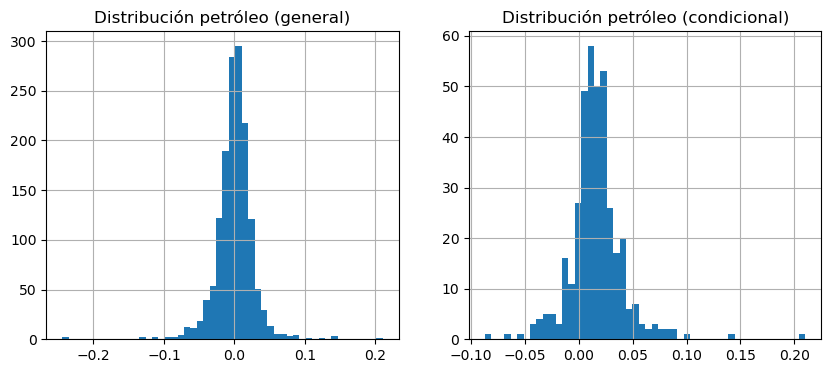

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
returns["oil"].hist(bins=50)
plt.title("Distribución petróleo (general)")

plt.subplot(1,2,2)
returns["oil"][returns["shell"] > 0.01].hist(bins=50)
plt.title("Distribución petróleo (condicional)")

plt.show()

La distribución de retornos del petróleo cambia significativamente bajo ciertas condiciones del mercado energético, mostrando un sesgo positivo cuando las acciones del sector presentan movimientos fuertes.

Conclusiones:

1. Existe correlación contemporánea moderada (~0.5)
2. No hay evidencia fuerte de causalidad lineal
3. Las petroleras muestran ligera anticipación sobre el petróleo
4. Existe una fuerte dependencia condicional:
   - Cuando las petroleras suben significativamente,
     el petróleo presenta retornos superiores

Interpretación:

El mercado energético presenta comportamiento no lineal,
donde ciertos eventos en las acciones contienen información
relevante sobre movimientos posteriores del petróleo.
